In [6]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
with open('../data/train.json', 'r') as f:
    train_data = json.load(f)

# Convert to DataFrame for easier analysis
df = pd.DataFrame.from_dict(train_data, orient='index')

print(f"Dataset loaded successfully!")
print(f"Total number of samples: {len(df)}")

Dataset loaded successfully!
Total number of samples: 2280


Train data is an object with keys and values in the form

```
"0": {
    "homonym": "potential",
    "judged_meaning": "the difference in electrical charge between two points in a circuit expressed in volts",
    "precontext": "The old machine hummed in the corner of the workshop. Clara examined its dusty dials with a furrowed brow. She wondered if it could be brought back to life.",
    "sentence": "The potential couldn't be measured.",
    "ending": "She collected a battery reader and looked on earnestly, willing some life back into the old machine.",
    "choices": [
        4,
        5,
        2,
        3,
        1
    ],
    "average": 3.0,
    "stdev": 1.5811388300841898,
    "nonsensical": [
        false,
        false,
        false,
        false,
        false
    ],
    "sample_id": "1843",
    "example_sentence": "The circuit has a high potential difference."
}```

## 1. General Statistics

In [7]:
# Basic dataset statistics
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total number of samples: {len(df)}")
print(f"Number of unique homonyms: {df['homonym'].nunique()}")
print(f"Number of unique sample IDs: {df['sample_id'].nunique()}")
print(f"\nColumns in dataset: {list(df.columns)}")

# Homonym distribution
print("\n" + "=" * 60)
print("HOMONYM DISTRIBUTION")
print("=" * 60)
homonym_counts = df['homonym'].value_counts()
print(f"\nTop 10 most frequent homonyms:")
print(homonym_counts.head(10))

# Rating statistics
print("\n" + "=" * 60)
print("RATING STATISTICS")
print("=" * 60)
# Flatten all choices to get individual ratings
all_ratings = []
for choices in df['choices']:
    all_ratings.extend(choices)

print(f"\nIndividual rating statistics:")
print(f"Total number of ratings: {len(all_ratings)}")
print(f"Mean rating: {np.mean(all_ratings):.2f}")
print(f"Median rating: {np.median(all_ratings):.2f}")
print(f"Min rating: {np.min(all_ratings)}")
print(f"Max rating: {np.max(all_ratings)}")
print(f"Standard deviation: {np.std(all_ratings):.2f}")

# Average rating per sample
print(f"\nAverage rating per sample:")
print(f"Mean: {df['average'].mean():.2f}")
print(f"Median: {df['average'].median():.2f}")
print(f"Min: {df['average'].min():.2f}")
print(f"Max: {df['average'].max():.2f}")
print(f"Standard deviation: {df['average'].std():.2f}")

# Standard deviation of ratings
print(f"\nStandard deviation of ratings per sample:")
print(f"Mean: {df['stdev'].mean():.2f}")
print(f"Median: {df['stdev'].median():.2f}")
print(f"Min: {df['stdev'].min():.2f}")
print(f"Max: {df['stdev'].max():.2f}")

# Nonsensical flag statistics
print("\n" + "=" * 60)
print("NONSENSICAL FLAG STATISTICS")
print("=" * 60)
nonsensical_counts = []
for nonsensical in df['nonsensical']:
    nonsensical_counts.extend(nonsensical)

nonsensical_true = sum(nonsensical_counts)
nonsensical_false = len(nonsensical_counts) - nonsensical_true
print(f"Total nonsensical flags: {len(nonsensical_counts)}")
print(f"True (nonsensical): {nonsensical_true} ({nonsensical_true/len(nonsensical_counts)*100:.2f}%)")
print(f"False (not nonsensical): {nonsensical_false} ({nonsensical_false/len(nonsensical_counts)*100:.2f}%)")

# Text length statistics
print("\n" + "=" * 60)
print("TEXT LENGTH STATISTICS")
print("=" * 60)
df['precontext_length'] = df['precontext'].str.len()
df['sentence_length'] = df['sentence'].str.len()
df['ending_length'] = df['ending'].str.len()
df['judged_meaning_length'] = df['judged_meaning'].str.len()

print(f"\nPrecontext length (characters):")
print(f"Mean: {df['precontext_length'].mean():.2f}")
print(f"Median: {df['precontext_length'].median():.2f}")

print(f"\nSentence length (characters):")
print(f"Mean: {df['sentence_length'].mean():.2f}")
print(f"Median: {df['sentence_length'].median():.2f}")

print(f"\nEnding length (characters):")
print(f"Mean: {df['ending_length'].mean():.2f}")
print(f"Median: {df['ending_length'].median():.2f}")

print(f"\nJudged meaning length (characters):")
print(f"Mean: {df['judged_meaning_length'].mean():.2f}")
print(f"Median: {df['judged_meaning_length'].median():.2f}")


DATASET OVERVIEW
Total number of samples: 2280
Number of unique homonyms: 220
Number of unique sample IDs: 2280

Columns in dataset: ['homonym', 'judged_meaning', 'precontext', 'sentence', 'ending', 'choices', 'average', 'stdev', 'nonsensical', 'sample_id', 'example_sentence']

HOMONYM DISTRIBUTION

Top 10 most frequent homonyms:
homonym
change       60
lousy        54
sentence     36
ring         36
snapped      30
cut          30
faculties    30
steps        30
serve        30
heated       24
Name: count, dtype: int64

RATING STATISTICS

Individual rating statistics:
Total number of ratings: 11434
Mean rating: 3.14
Median rating: 3.00
Min rating: 1
Max rating: 5
Standard deviation: 1.53

Average rating per sample:
Mean: 3.14
Median: 3.20
Min: 1.00
Max: 5.00
Standard deviation: 1.19

Standard deviation of ratings per sample:
Mean: 0.95
Median: 0.89
Min: 0.00
Max: 2.19

NONSENSICAL FLAG STATISTICS
Total nonsensical flags: 11434
True (nonsensical): 268 (2.34%)
False (not nonsensical): 1

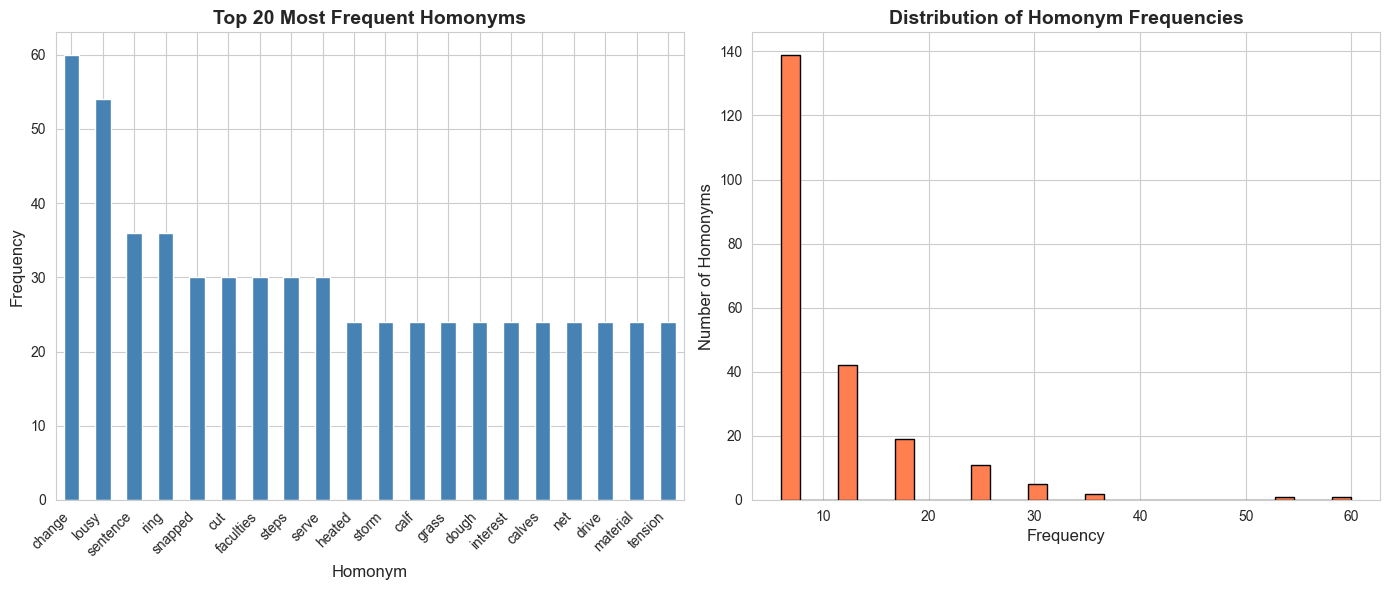

Total unique homonyms: 220
Homonyms appearing only once: 0
Homonyms appearing 10+ times: 81


In [8]:
# 1. Homonym distribution
plt.figure(figsize=(14, 6))
homonym_counts = df['homonym'].value_counts()
top_homonyms = homonym_counts.head(20)

plt.subplot(1, 2, 1)
top_homonyms.plot(kind='bar', color='steelblue')
plt.title('Top 20 Most Frequent Homonyms', fontsize=14, fontweight='bold')
plt.xlabel('Homonym', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.subplot(1, 2, 2)
homonym_counts.plot(kind='hist', bins=30, color='coral', edgecolor='black')
plt.title('Distribution of Homonym Frequencies', fontsize=14, fontweight='bold')
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Number of Homonyms', fontsize=12)
plt.tight_layout()

plt.tight_layout()
plt.show()

print(f"Total unique homonyms: {df['homonym'].nunique()}")
print(f"Homonyms appearing only once: {(homonym_counts == 1).sum()}")
print(f"Homonyms appearing 10+ times: {(homonym_counts >= 10).sum()}")


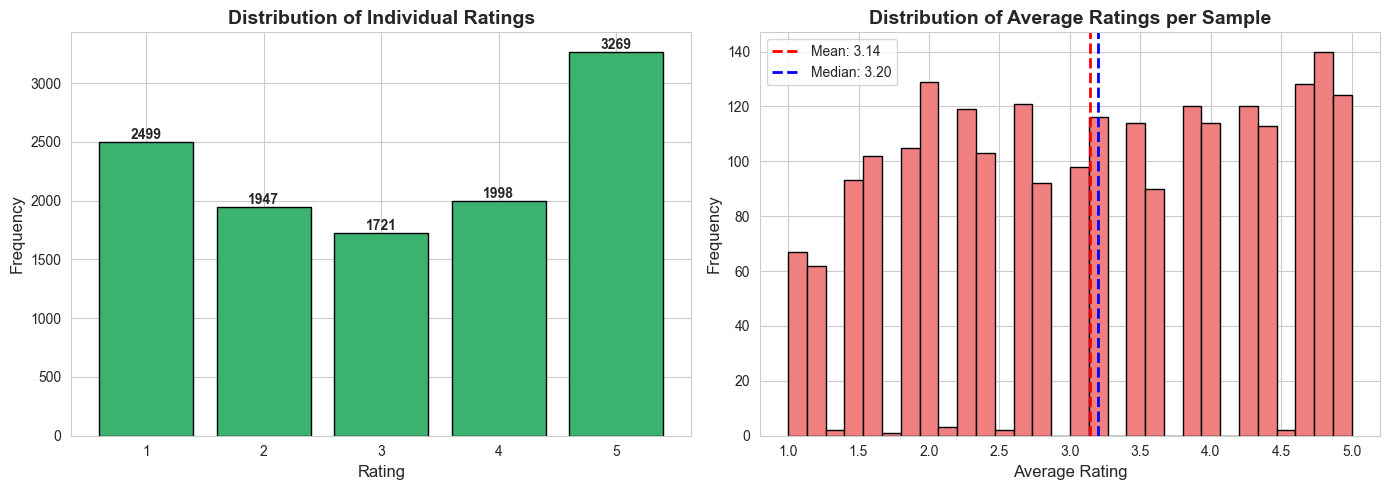

In [9]:
# 2. Rating distribution
plt.figure(figsize=(14, 5))

# Flatten all choices
all_ratings = []
for choices in df['choices']:
    all_ratings.extend(choices)

plt.subplot(1, 2, 1)
rating_counts = Counter(all_ratings)
ratings = sorted(rating_counts.keys())
counts = [rating_counts[r] for r in ratings]
plt.bar(ratings, counts, color='mediumseagreen', edgecolor='black')
plt.title('Distribution of Individual Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(ratings)
for i, (r, c) in enumerate(zip(ratings, counts)):
    plt.text(r, c, str(c), ha='center', va='bottom', fontweight='bold')

plt.subplot(1, 2, 2)
plt.hist(df['average'], bins=30, color='lightcoral', edgecolor='black')
plt.title('Distribution of Average Ratings per Sample', fontsize=14, fontweight='bold')
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(df['average'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["average"].mean():.2f}')
plt.axvline(df['average'].median(), color='blue', linestyle='--', linewidth=2, label=f'Median: {df["average"].median():.2f}')
plt.legend()

plt.tight_layout()
plt.show()


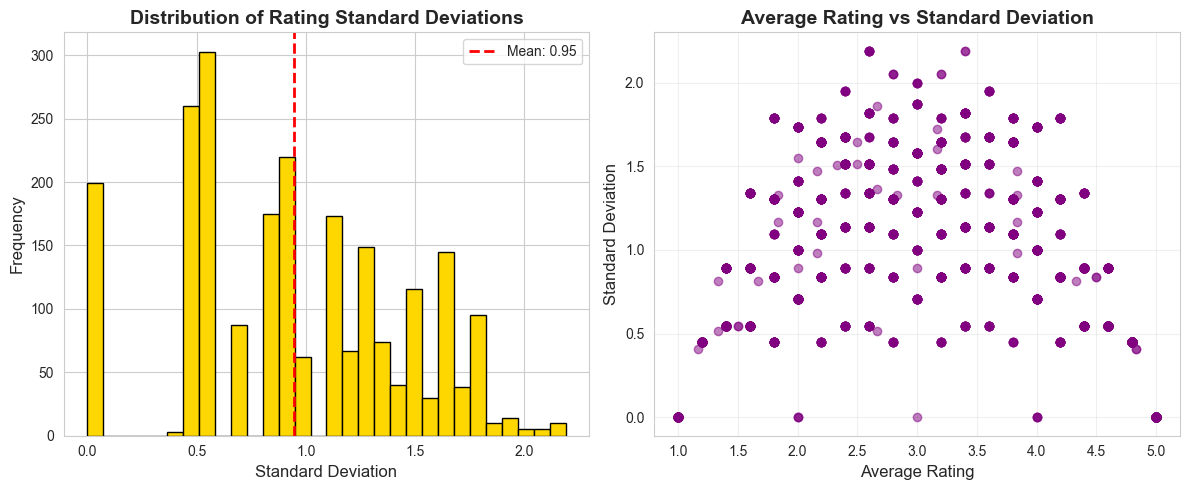

Correlation between average rating and standard deviation: -0.138


In [10]:
# 3. Standard deviation of ratings
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['stdev'], bins=30, color='gold', edgecolor='black')
plt.title('Distribution of Rating Standard Deviations', fontsize=14, fontweight='bold')
plt.xlabel('Standard Deviation', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(df['stdev'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["stdev"].mean():.2f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(df['average'], df['stdev'], alpha=0.5, color='purple')
plt.title('Average Rating vs Standard Deviation', fontsize=14, fontweight='bold')
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Standard Deviation', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation
correlation = df['average'].corr(df['stdev'])
print(f"Correlation between average rating and standard deviation: {correlation:.3f}")


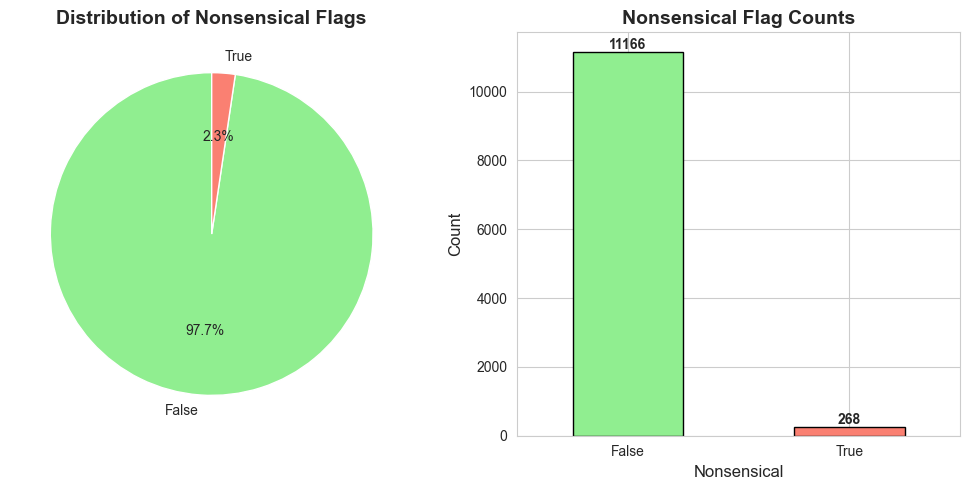

In [11]:
# 4. Nonsensical flag analysis
nonsensical_counts = []
for nonsensical in df['nonsensical']:
    nonsensical_counts.extend(nonsensical)

nonsensical_df = pd.DataFrame({'nonsensical': nonsensical_counts})
nonsensical_summary = nonsensical_df['nonsensical'].value_counts()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
colors = ['lightgreen', 'salmon']
nonsensical_summary.plot(kind='pie', autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Distribution of Nonsensical Flags', fontsize=14, fontweight='bold')
plt.ylabel('')

plt.subplot(1, 2, 2)
nonsensical_summary.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Nonsensical Flag Counts', fontsize=14, fontweight='bold')
plt.xlabel('Nonsensical', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1], ['False', 'True'], rotation=0)
for i, v in enumerate(nonsensical_summary.values):
    plt.text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


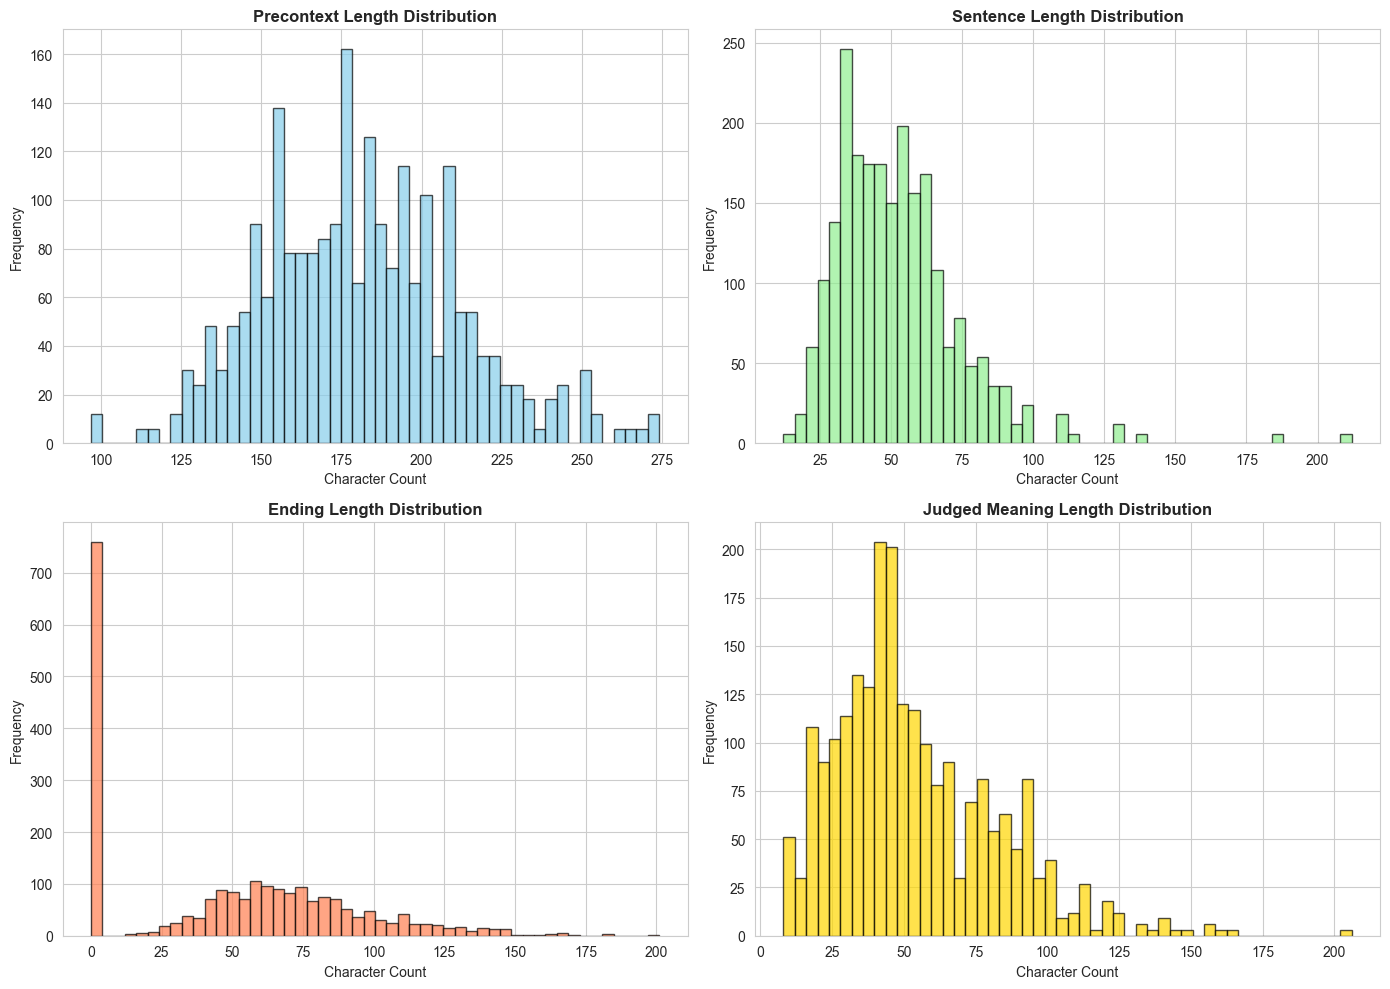

In [ ]:
# 5. Text length distributions (nu stiu cat de mult conteaza asta)
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.hist(df['precontext_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Precontext Length Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Character Count', fontsize=10)
plt.ylabel('Frequency', fontsize=10)

plt.subplot(2, 2, 2)
plt.hist(df['sentence_length'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
plt.title('Sentence Length Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Character Count', fontsize=10)
plt.ylabel('Frequency', fontsize=10)

plt.subplot(2, 2, 3)
plt.hist(df['ending_length'], bins=50, color='coral', edgecolor='black', alpha=0.7)
plt.title('Ending Length Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Character Count', fontsize=10)
plt.ylabel('Frequency', fontsize=10)

plt.subplot(2, 2, 4)
plt.hist(df['judged_meaning_length'], bins=50, color='gold', edgecolor='black', alpha=0.7)
plt.title('Judged Meaning Length Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Character Count', fontsize=10)
plt.ylabel('Frequency', fontsize=10)

plt.tight_layout()
plt.show()


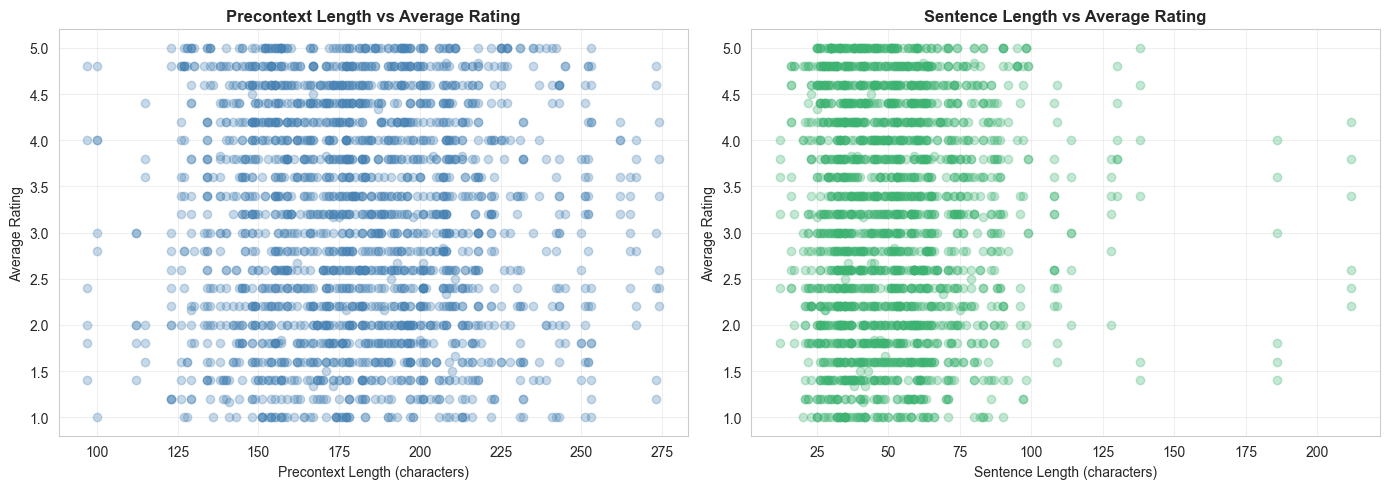

Correlation between precontext length and average rating: -0.013
Correlation between sentence length and average rating: 0.024


In [13]:
# 6. Relationship between text length and ratings
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(df['precontext_length'], df['average'], alpha=0.3, color='steelblue')
plt.title('Precontext Length vs Average Rating', fontsize=12, fontweight='bold')
plt.xlabel('Precontext Length (characters)', fontsize=10)
plt.ylabel('Average Rating', fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(df['sentence_length'], df['average'], alpha=0.3, color='mediumseagreen')
plt.title('Sentence Length vs Average Rating', fontsize=12, fontweight='bold')
plt.xlabel('Sentence Length (characters)', fontsize=10)
plt.ylabel('Average Rating', fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation coefficients
print(f"Correlation between precontext length and average rating: {df['precontext_length'].corr(df['average']):.3f}")
print(f"Correlation between sentence length and average rating: {df['sentence_length'].corr(df['average']):.3f}")


<Figure size 1400x600 with 0 Axes>

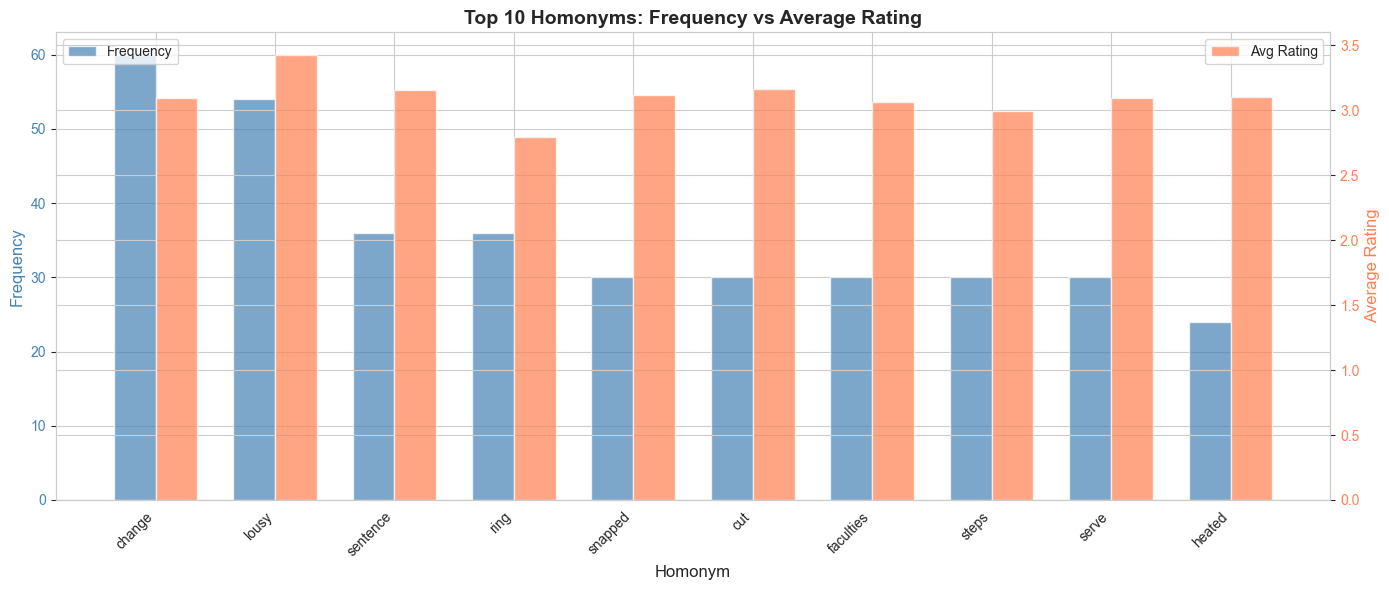

In [14]:
# 7. Top homonyms with their average ratings
top_10_homonyms = df['homonym'].value_counts().head(10).index

plt.figure(figsize=(14, 6))
homonym_avg_ratings = df.groupby('homonym')['average'].mean().loc[top_10_homonyms]
homonym_counts_subset = df['homonym'].value_counts().loc[top_10_homonyms]

x = np.arange(len(top_10_homonyms))
width = 0.35

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

bars1 = ax1.bar(x - width/2, homonym_counts_subset.values, width, label='Frequency', color='steelblue', alpha=0.7)
bars2 = ax2.bar(x + width/2, homonym_avg_ratings.values, width, label='Avg Rating', color='coral', alpha=0.7)

ax1.set_xlabel('Homonym', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12, color='steelblue')
ax2.set_ylabel('Average Rating', fontsize=12, color='coral')
ax1.set_title('Top 10 Homonyms: Frequency vs Average Rating', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(top_10_homonyms, rotation=45, ha='right')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='coral')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


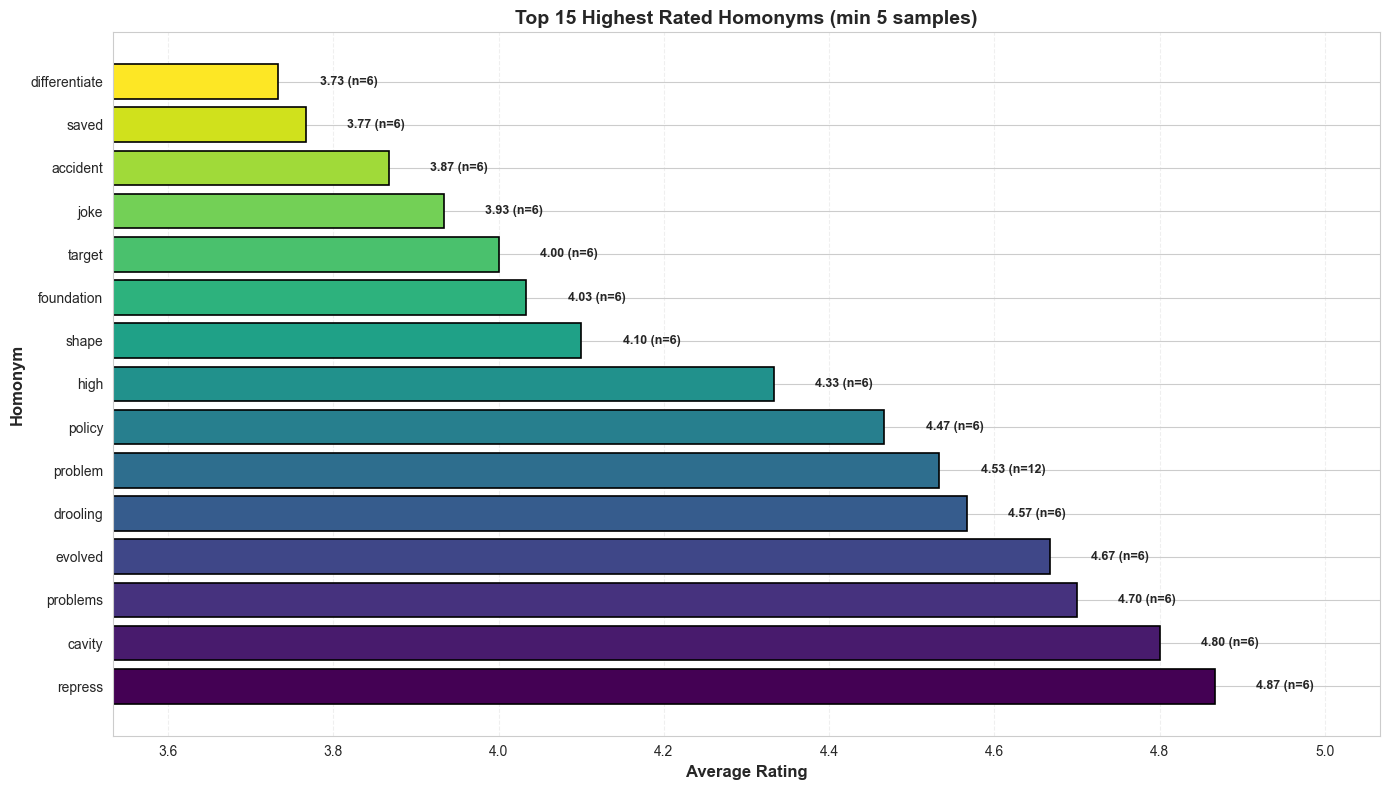


Top 15 highest rated homonyms (with at least 5 samples):
      homonym  average  count
      repress 4.866667      6
       cavity 4.800000      6
     problems 4.700000      6
      evolved 4.666667      6
     drooling 4.566667      6
      problem 4.533333     12
       policy 4.466667      6
         high 4.333333      6
        shape 4.100000      6
   foundation 4.033333      6
       target 4.000000      6
         joke 3.933333      6
     accident 3.866667      6
        saved 3.766667      6
differentiate 3.733333      6


In [19]:
# 8. Top rated homonyms (by average rating)
# Calculate average rating per homonym with minimum sample size requirement
homonym_stats = df.groupby('homonym').agg({
    'average': 'mean',
    'homonym': 'count'  # count of samples per homonym
}).rename(columns={'homonym': 'count'}).reset_index()

# Filter homonyms with at least k samples for more reliable statistics
min_samples = 5
homonym_stats_filtered = homonym_stats[homonym_stats['count'] >= min_samples].copy()

# Get top 15 highest rated homonyms
top_rated = homonym_stats_filtered.nlargest(15, 'average')

plt.figure(figsize=(14, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(top_rated)))

bars = plt.barh(range(len(top_rated)), top_rated['average'].values, color=colors, edgecolor='black', linewidth=1.2)
plt.yticks(range(len(top_rated)), top_rated['homonym'].values)
plt.xlabel('Average Rating', fontsize=12, fontweight='bold')
plt.ylabel('Homonym', fontsize=12, fontweight='bold')
plt.title(f'Top 15 Highest Rated Homonyms (min {min_samples} samples)', fontsize=14, fontweight='bold')
plt.xlim([top_rated['average'].min() - 0.2, top_rated['average'].max() + 0.2])
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (idx, row) in enumerate(top_rated.iterrows()):
    plt.text(row['average'] + 0.05, i, f"{row['average']:.2f} (n={int(row['count'])})", 
             va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nTop 15 highest rated homonyms (with at least {min_samples} samples):")
print(top_rated[['homonym', 'average', 'count']].to_string(index=False))
